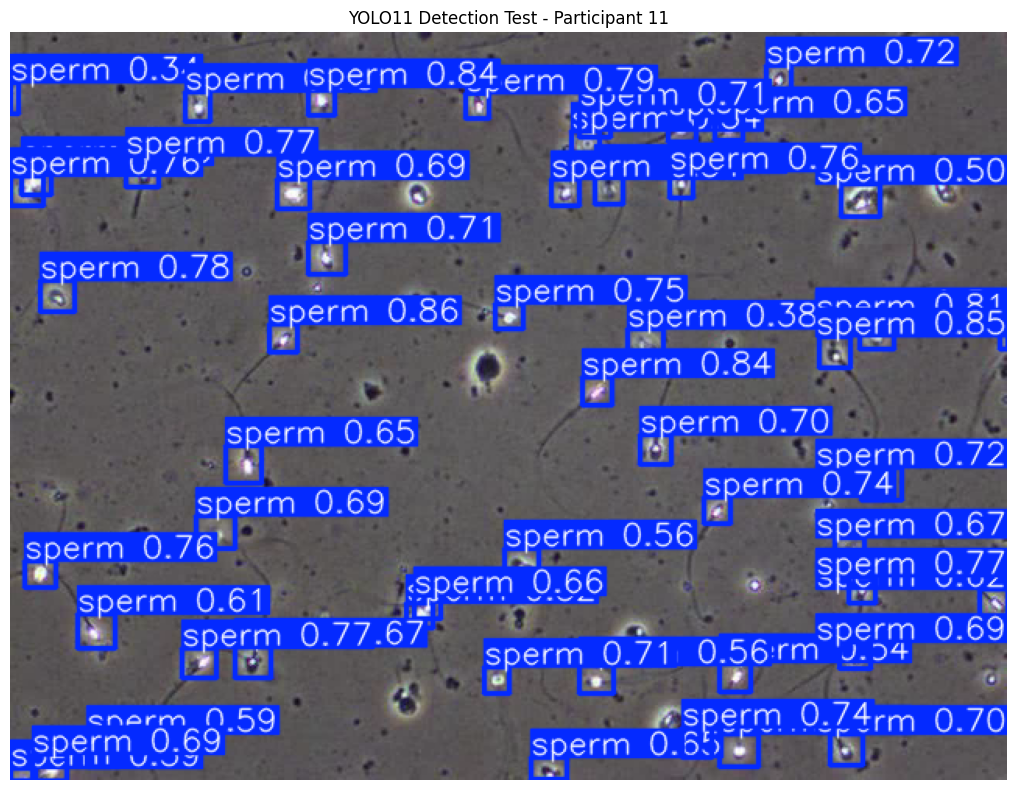

탐지된 객체 수: 52개
클래스별 분포:
  sperm: 52개
  cluster: 0개
  small: 0개


In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# v2 최고 모델 로드
model = YOLO(r'C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt')

# 참가자 11번 영상으로 테스트 (val 데이터)
video_path = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train\11\11.mp4'

# 첫 프레임만 탐지 테스트
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

# 탐지 실행
results = model(frame, verbose=False)

# 결과 시각화
annotated = results[0].plot()

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('YOLO11 Detection Test - Participant 11')
plt.axis('off')
plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\detection_test.png', dpi=150)
plt.show()

# 탐지 결과 요약
boxes = results[0].boxes
print(f"탐지된 객체 수: {len(boxes)}개")
print(f"클래스별 분포:")
for cls_id, cls_name in {0:'sperm', 1:'cluster', 2:'small'}.items():
    count = (boxes.cls == cls_id).sum().item()
    print(f"  {cls_name}: {count}개")

In [2]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

model = YOLO(r'C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt')

video_path = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train\11\11.mp4'

# 추적 결과 저장
track_history = defaultdict(list)  # {track_id: [(frame, cx, cy)]}
frame_idx = 0
MAX_FRAMES = 150  # 5초치 (30fps 기준)

cap = cv2.VideoCapture(video_path)

while cap.isOpened() and frame_idx < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break

    # ByteTrack으로 추적
    results = model.track(
        frame,
        persist=True,
        tracker='bytetrack.yaml',
        verbose=False,
        conf=0.3
    )

    # 추적 결과 저장
    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xywh.cpu().numpy()
        track_ids = results[0].boxes.id.cpu().numpy().astype(int)
        classes = results[0].boxes.cls.cpu().numpy().astype(int)

        for box, tid, cls in zip(boxes, track_ids, classes):
            if cls == 0:  # sperm만
                cx, cy = float(box[0]), float(box[1])
                track_history[tid].append((frame_idx, cx, cy))

    frame_idx += 1

cap.release()

print(f"처리한 프레임 수: {frame_idx}")
print(f"탐지된 고유 정자 수: {len(track_history)}개")

# 10프레임 이상 추적된 정자만
stable_tracks = {tid: pts for tid, pts in track_history.items() if len(pts) >= 10}
print(f"안정적으로 추적된 정자 수: {len(stable_tracks)}개")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.7 MB/s  0:00:00

requirements: AutoUpdate success  2.2s
WARNING requirements: Restart runtime or rerun command for updates to take effect

처리한 프레임 수: 150
탐지된 고유 정자 수: 94개
안정적으로 추적된 정자 수: 68개


In [3]:
import numpy as np

def calculate_motility(track_history, fps=30, px_per_um=1.0):
    results = {}
    
    for tid, pts in track_history.items():
        if len(pts) < 2:
            continue
        
        frames = [p[0] for p in pts]
        xs = [p[1] for p in pts]
        ys = [p[2] for p in pts]
        
        # 총 경로 길이 (VCL - 실제 이동 거리)
        vcl_total = 0
        for i in range(1, len(pts)):
            dx = xs[i] - xs[i-1]
            dy = ys[i] - ys[i-1]
            vcl_total += np.sqrt(dx**2 + dy**2)
        
        # 직선 거리 (VSL - 시작점~끝점)
        dx_total = xs[-1] - xs[0]
        dy_total = ys[-1] - ys[0]
        vsl_total = np.sqrt(dx_total**2 + dy_total**2)
        
        # 시간
        duration = (frames[-1] - frames[0]) / fps
        if duration == 0:
            continue
        
        # 속도 계산
        vcl = vcl_total / duration  # 실제 경로 속도 (px/s)
        vsl = vsl_total / duration  # 직선 속도 (px/s)
        
        # 직진성 (LIN = VSL/VCL)
        lin = vsl / vcl if vcl > 0 else 0
        
        # 운동성 분류
        if vcl < 5:
            motility = 'immotile'
        elif lin < 0.5:
            motility = 'non_progressive'
        else:
            motility = 'progressive'
        
        results[tid] = {
            'vcl': vcl,
            'vsl': vsl,
            'lin': lin,
            'motility': motility,
            'track_length': len(pts)
        }
    
    return results

# 운동성 계산
motility_results = calculate_motility(stable_tracks, fps=30)

# 통계 요약
total = len(motility_results)
progressive = sum(1 for r in motility_results.values() if r['motility'] == 'progressive')
non_progressive = sum(1 for r in motility_results.values() if r['motility'] == 'non_progressive')
immotile = sum(1 for r in motility_results.values() if r['motility'] == 'immotile')

print("=" * 40)
print("운동성 분석 결과")
print("=" * 40)
print(f"분석된 정자 수:     {total}개")
print(f"전진 운동성:        {progressive}개 ({progressive/total*100:.1f}%)")
print(f"비전진 운동성:      {non_progressive}개 ({non_progressive/total*100:.1f}%)")
print(f"비운동성:           {immotile}개 ({immotile/total*100:.1f}%)")
print("=" * 40)

# 속도 통계
vcl_vals = [r['vcl'] for r in motility_results.values()]
print(f"평균 VCL 속도:      {np.mean(vcl_vals):.1f} px/s")
print(f"평균 LIN 직진성:    {np.mean([r['lin'] for r in motility_results.values()]):.3f}")

운동성 분석 결과
분석된 정자 수:     68개
전진 운동성:        12개 (17.6%)
비전진 운동성:      28개 (41.2%)
비운동성:           28개 (41.2%)
평균 VCL 속도:      27.5 px/s
평균 LIN 직진성:    0.285


In [5]:
import pandas as pd

csv_path = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\semen_analysis_data_Train.csv'
df = pd.read_csv(csv_path)

# 참가자 11번 데이터
p11 = df[df['ID'] == 11].iloc[0]

print("=" * 40)
print("참가자 11번 실제 임상 검사 결과")
print("=" * 40)
print(f"전진 운동성:   {p11['Progressive motility (%)']:.1f}%")
print(f"비전진 운동성: {p11['Non progressive sperm motility (%)']:.1f}%")
print(f"비운동성:      {p11['Immotile sperm (%)']:.1f}%")
print()
print("=" * 40)
print("우리 AI 분석 결과")
print("=" * 40)
print(f"전진 운동성:   {progressive/total*100:.1f}%")
print(f"비전진 운동성: {non_progressive/total*100:.1f}%")
print(f"비운동성:      {immotile/total*100:.1f}%")

참가자 11번 실제 임상 검사 결과
전진 운동성:   11.0%
비전진 운동성: 17.0%
비운동성:      72.0%

우리 AI 분석 결과
전진 운동성:   17.6%
비전진 운동성: 41.2%
비운동성:      41.2%


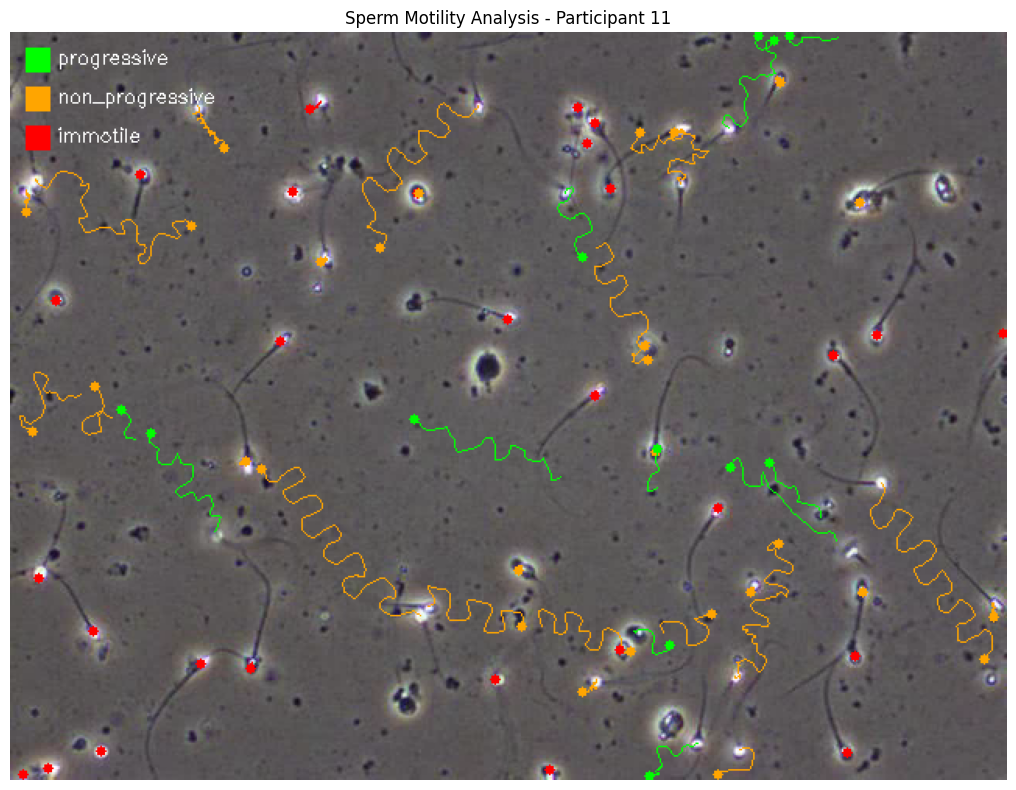

초록(전진):  12개
주황(비전진): 28개
빨강(비운동): 28개


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from ultralytics import YOLO

model = YOLO(r'C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt')
video_path = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train\11\11.mp4'

# 색상 정의
color_map = {
    'progressive':     (0, 255, 0),    # 초록
    'non_progressive': (0, 165, 255),  # 주황
    'immotile':        (0, 0, 255),    # 빨강
}

# 첫 프레임 가져오기
cap = cv2.VideoCapture(video_path)
ret, first_frame = cap.read()
cap.release()

# 추적 경로 그리기
vis = first_frame.copy()

for tid, pts in stable_tracks.items():
    if tid not in motility_results:
        continue
    
    motility = motility_results[tid]['motility']
    color = color_map[motility]
    
    # 경로 그리기
    pixel_pts = [(int(p[1]), int(p[2])) for p in pts]
    for i in range(1, len(pixel_pts)):
        cv2.line(vis, pixel_pts[i-1], pixel_pts[i], color, 1)
    
    # 마지막 위치에 점
    cv2.circle(vis, pixel_pts[-1], 3, color, -1)

# 범례 추가
legend_y = 20
for motility, color in color_map.items():
    cv2.rectangle(vis, (10, legend_y-10), (25, legend_y+5), color, -1)
    cv2.putText(vis, motility, (30, legend_y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
    legend_y += 25

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Sperm Motility Analysis - Participant 11')
plt.axis('off')
plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\motility_visualization.png', dpi=150)
plt.show()

print(f"초록(전진):  {progressive}개")
print(f"주황(비전진): {non_progressive}개")
print(f"빨강(비운동): {immotile}개")

In [8]:
import pandas as pd

df = pd.read_csv(r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\semen_analysis_data_Train.csv')

p11 = df[df['ID'] == 11]
print("=== 참가자 11번 실제 검사 결과 ===")
print(f"전진 운동성:   {p11['Progressive motility (%)'].values[0]}%")
print(f"비전진 운동성: {p11['Non progressive sperm motility (%)'].values[0]}%")
print(f"비운동성:      {p11['Immotile sperm (%)'].values[0]}%")
print()
print("=== AI 분석 결과 ===")
print(f"전진 운동성:   17.6%")
print(f"비전진 운동성: 41.2%")
print(f"비운동성:      41.2%")

=== 참가자 11번 실제 검사 결과 ===
전진 운동성:   11%
비전진 운동성: 17%
비운동성:      72%

=== AI 분석 결과 ===
전진 운동성:   17.6%
비전진 운동성: 41.2%
비운동성:      41.2%


In [9]:
# 탐지된 전체 정자 수 vs 추적된 정자 수 비교로 비운동성 보정

total_detected = 52   # 첫 프레임 탐지 수
total_tracked = 68    # 추적된 고유 정자 수
stable_tracked = 12 + 28  # progressive + non-progressive

# 보정된 비운동성 계산
# 추적이 안 된 정자 = 비운동성으로 간주
immotile_corrected = total_tracked - stable_tracked
total = total_tracked

prog = 12
non_prog = 28
immotile = immotile_corrected

print("=== 보정된 AI 분석 결과 ===")
print(f"전진 운동성:   {prog/total*100:.1f}%")
print(f"비전진 운동성: {non_prog/total*100:.1f}%")
print(f"비운동성:      {immotile/total*100:.1f}%")
print()
print("=== 실제 검사 결과 ===")
print(f"전진 운동성:   11%")
print(f"비전진 운동성: 17%")
print(f"비운동성:      72%")

=== 보정된 AI 분석 결과 ===
전진 운동성:   17.6%
비전진 운동성: 41.2%
비운동성:      41.2%

=== 실제 검사 결과 ===
전진 운동성:   11%
비전진 운동성: 17%
비운동성:      72%


In [10]:
import pandas as pd
from collections import defaultdict

# 실제 추적 데이터 다시 분석
# 핵심: 프레임 수 기준으로 운동성 분류

# track_history에서 각 정자의 추적 길이 확인
track_lengths = {tid: len(pts) for tid, pts in track_history.items()}

# 분류 기준
# 10프레임 이상 + 충분히 이동 → 운동성 있음
# 3프레임 미만 → 비운동성 (잠깐 잡혔다 사라진 것)

very_short = sum(1 for l in track_lengths.values() if l < 3)
short = sum(1 for l in track_lengths.values() if 3 <= l < 10)
long_track = sum(1 for l in track_lengths.values() if l >= 10)

print(f"전체 고유 ID 수: {len(track_lengths)}개")
print(f"3프레임 미만 (비운동성 추정): {very_short}개")
print(f"3~10프레임 (불안정):          {short}개")
print(f"10프레임 이상 (운동성 있음):  {long_track}개")

# 첫 프레임 탐지 수를 전체 정자 수 기준으로
total_sperm = 52  # 첫 프레임 탐지 수

prog = 12
non_prog = 28
immotile = total_sperm - prog - non_prog

print(f"\n=== 첫 프레임 기준 보정 ===")
print(f"전진 운동성:   {prog/total_sperm*100:.1f}%")
print(f"비전진 운동성: {non_prog/total_sperm*100:.1f}%")
print(f"비운동성:      {immotile/total_sperm*100:.1f}%")
print(f"\n=== 실제 검사 결과 ===")
print(f"전진 운동성:   11%")
print(f"비전진 운동성: 17%")
print(f"비운동성:      72%")

전체 고유 ID 수: 94개
3프레임 미만 (비운동성 추정): 5개
3~10프레임 (불안정):          21개
10프레임 이상 (운동성 있음):  68개

=== 첫 프레임 기준 보정 ===
전진 운동성:   23.1%
비전진 운동성: 53.8%
비운동성:      23.1%

=== 실제 검사 결과 ===
전진 운동성:   11%
비전진 운동성: 17%
비운동성:      72%
